In [1]:
!pip install pyhive sqlalchemy
!pip install thrift
!pip install thrift_sasl
!pip install sqlalchemy pyhive thrift

In [3]:
from sqlalchemy import create_engine
import pandas as pd

# Crea la conexión usando SQLAlchemy
engine = create_engine('hive://hiveserver2:10000/default')

# Define tu consulta
query = """
SELECT
    p.path,
    p.tper AS total_per,
    l.tloc AS total_loc
FROM
    default.wikinerper_count p
JOIN
    default.wikinerloc_count l
ON
    TRIM(p.path) = TRIM(l.path)
"""

# Ejecuta la consulta y guarda el resultado en un DataFrame
df = pd.read_sql(query, engine)

# Imprime el DataFrame
print(df)



                                                  path  total_per  total_loc
0                            %C3%81baco_neperiano.html          4          4
1                                  %C3%81msterdam.html          2         96
2                                       %C3%81rea.html          4          8
3                                %C3%89xodo_rural.html          2         20
4                                            1927.html          2          4
..                                                 ...        ...        ...
205                              Vincent_van_Gogh.html         20         20
206  Vista_del_Alc%C3%A1zar_Real_y_entorno_del_Puen...          2         36
207                                     Yihadismo.html          6          4
208                                      Zarzuela.html          6         16
209                                 Zurbar%C3%A1n.html         28         28

[210 rows x 3 columns]


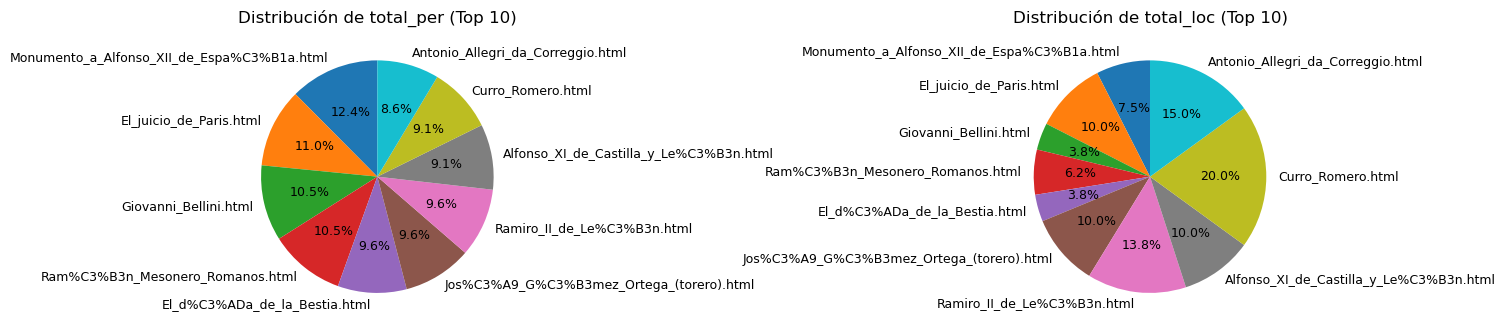

In [4]:
import matplotlib.pyplot as plt

top_n = 10
df_top = df.nlargest(top_n, 'total_per')

# Creamos figura con dos subplots
fig, axes = plt.subplots(1, 2, figsize=(14, 7))

# Pie chart para total_per
axes[0].pie(
    df_top['total_per'],
    labels=df_top['path'],
    autopct='%1.1f%%',
    startangle=90,
    textprops={'fontsize': 9}
)
axes[0].set_title('Distribución de total_per (Top 10)')

# Pie chart para total_loc
axes[1].pie(
    df_top['total_loc'],
    labels=df_top['path'],
    autopct='%1.1f%%',
    startangle=90,
    textprops={'fontsize': 9}
)
axes[1].set_title('Distribución de total_loc (Top 10)')

plt.tight_layout()
plt.show()
